#Dataset link:https://www.kaggle.com/datasets/uwrfkaggler/ravdess-facial-landmark-tracking

#1. Ashiq Shaik (35033254)

In [1]:
# =========================
# 1. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# =========================
# 2. Install required package
# =========================
!pip -q install xgboost

In [3]:
# =========================
# 3. Imports
# =========================
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# =========================
# 4. Set dataset folder path
# =========================
# Change this path if needed
dataset_dir = "/content/drive/MyDrive/Face dataset"

print("Dataset folder exists:", os.path.exists(dataset_dir))

Dataset folder exists: False


In [5]:
# =========================
# 5. Find all CSV files recursively
# =========================
csv_files = glob.glob(os.path.join(dataset_dir, "**", "*.csv"), recursive=True)

print("Total CSV files found:", len(csv_files))
print("Sample files:")
for f in csv_files[:5]:
    print(f)


Total CSV files found: 0
Sample files:


In [6]:
# =========================
# 6. Emotion mapping from filename
# RAVDESS-style code:
# 01 = neutral
# 02 = calm
# 03 = happy
# 04 = sad
# 05 = angry
# 06 = fear
# 07 = disgust
# 08 = surprised
# =========================
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprised"
}

def get_emotion_from_filename(filepath):
    filename = os.path.basename(filepath).replace(".csv", "")
    parts = filename.split("-")
    if len(parts) >= 3:
        emotion_code = parts[2]
        return emotion_map.get(emotion_code, "unknown")
    return "unknown"


#2. Mohammed Suleman (35049043)

In [7]:
# =========================
# 7. Read one sample file
# =========================
sample_df = pd.read_csv(csv_files[0])
print("\nSample file shape:", sample_df.shape)
print("\nFirst 20 columns:")
print(sample_df.columns[:20].tolist())

IndexError: list index out of range

In [ ]:
# =========================
# 8. Select useful columns
# Fast + strong features:
# gaze, pose, AU, confidence, success
# =========================
all_cols = sample_df.columns.tolist()

selected_cols = []
for col in all_cols:
    if (
        col.startswith("gaze_") or
        col.startswith("pose_") or
        col.startswith("AU")
    ):
        selected_cols.append(col)

if "confidence" in all_cols:
    selected_cols.append("confidence")

if "success" in all_cols:
    selected_cols.append("success")

print("\nSelected feature columns:", len(selected_cols))
print(selected_cols[:20])


Selected feature columns: 50
['gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x', 'gaze_angle_y', 'pose_Tx', 'pose_Ty', 'pose_Tz', 'pose_Rx', 'pose_Ry', 'pose_Rz', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r']


In [ ]:
# =========================
# 9. Feature extraction
# For each CSV file:
# mean, std, min, max, median
# =========================
def extract_features_from_csv(filepath, selected_cols):
    try:
        df = pd.read_csv(filepath)

        cols = [c for c in selected_cols if c in df.columns]
        df = df[cols].copy()

        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(df.median(numeric_only=True))
        df = df.fillna(0)

        feature_dict = {}

        for c in df.columns:
            values = df[c].values.astype(np.float32)

            feature_dict[f"{c}_mean"] = np.mean(values)
            feature_dict[f"{c}_std"] = np.std(values)
            feature_dict[f"{c}_min"] = np.min(values)
            feature_dict[f"{c}_max"] = np.max(values)
            feature_dict[f"{c}_median"] = np.median(values)

        return feature_dict

    except Exception as e:
        return None

In [ ]:
# =========================
# 10. Build dataset
# =========================
data_rows = []

for i, file_path in enumerate(csv_files):
    label = get_emotion_from_filename(file_path)
    if label == "unknown":
        continue

    feats = extract_features_from_csv(file_path, selected_cols)
    if feats is None:
        continue

    feats["label"] = label
    feats["file_name"] = os.path.basename(file_path)
    feats["full_path"] = file_path
    data_rows.append(feats)

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(csv_files)} files")

dataset_df = pd.DataFrame(data_rows)

print("\nFinal dataset shape:", dataset_df.shape)
print("\nClass counts:")
print(dataset_df["label"].value_counts())

Processed 200/2452 files
Processed 400/2452 files
Processed 600/2452 files
Processed 800/2452 files
Processed 1000/2452 files
Processed 1200/2452 files
Processed 1400/2452 files
Processed 1600/2452 files
Processed 1800/2452 files
Processed 2000/2452 files
Processed 2200/2452 files
Processed 2400/2452 files

Final dataset shape: (2452, 253)

Class counts:
label
calm         376
sad          376
happy        376
angry        376
fear         376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64


#3. Pamulapati Mahesh Babu (35045493)

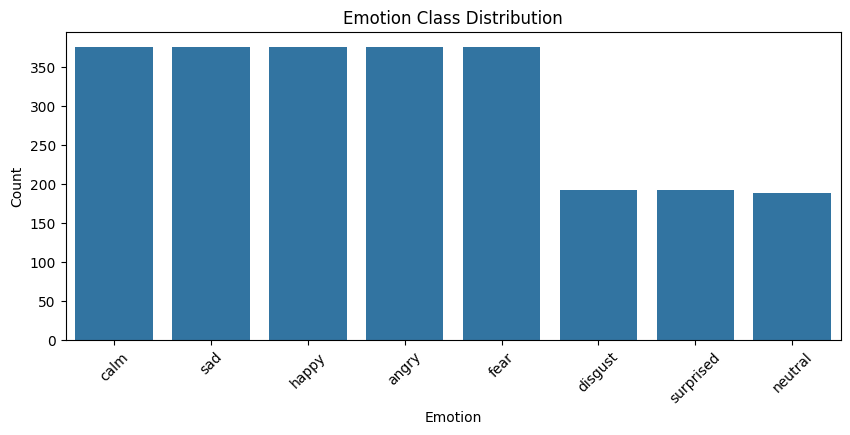

In [ ]:
# =========================
# 11. Plot class distribution
# =========================
plt.figure(figsize=(10, 4))
sns.countplot(x="label", data=dataset_df, order=dataset_df["label"].value_counts().index)
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# =========================
# 12. Prepare X and y
# =========================
X = dataset_df.drop(columns=["label", "file_name", "full_path"])
y = dataset_df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes:")
print(list(label_encoder.classes_))


Encoded classes:
['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprised']


In [ ]:
# =========================
# 13. Train/Val/Test split
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1568, 250)
Validation shape: (393, 250)
Test shape: (491, 250)


In [ ]:
# =========================
# 14. Define fast strong models
# =========================
models = {
    "ExtraTrees": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", ExtraTreesClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=180,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

#4.Nikhilesh Andole (35040343)


Training ExtraTrees...
ExtraTrees Validation Accuracy: 0.8982

Training RandomForest...
RandomForest Validation Accuracy: 0.8804

Training XGBoost...
XGBoost Validation Accuracy: 0.8779

Model Comparison:
          Model  Validation Accuracy
0    ExtraTrees             0.898219
1  RandomForest             0.880407
2       XGBoost             0.877863


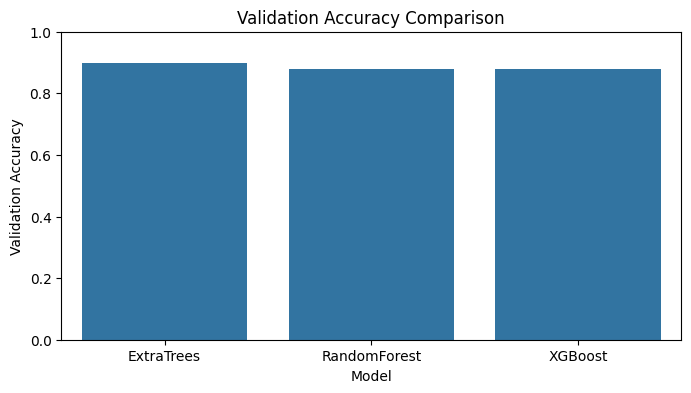

In [ ]:
# =========================
# 15. Train models and compare
# =========================
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    results.append((name, val_acc))
    print(f"{name} Validation Accuracy: {val_acc:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])
results_df = results_df.sort_values(by="Validation Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


In [ ]:
# =========================
# 16. Select best model
# =========================
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest model selected: {best_model_name}")

# Retrain on full train+validation data
best_model.fit(X_train_full, y_train_full)


Best model selected: ExtraTrees


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 ExtraTreesClassifier(n_estimators=250, n_jobs=-1,
                                      random_state=42))])

#5.Rajagopala Rao Bandaru (35050526)

In [ ]:
# =========================
# 17. Test evaluation
# =========================
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nFinal Test Accuracy ({best_model_name}): {test_acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=label_encoder.classes_
))


Final Test Accuracy (ExtraTrees): 0.9002

Classification Report:

              precision    recall  f1-score   support

       angry       0.90      0.96      0.93        75
        calm       0.94      0.96      0.95        75
     disgust       0.90      0.95      0.93        39
        fear       0.82      0.89      0.85        75
       happy       0.94      1.00      0.97        75
     neutral       0.84      0.97      0.90        38
         sad       0.94      0.81      0.87        75
   surprised       0.95      0.54      0.69        39

    accuracy                           0.90       491
   macro avg       0.90      0.89      0.89       491
weighted avg       0.90      0.90      0.90       491



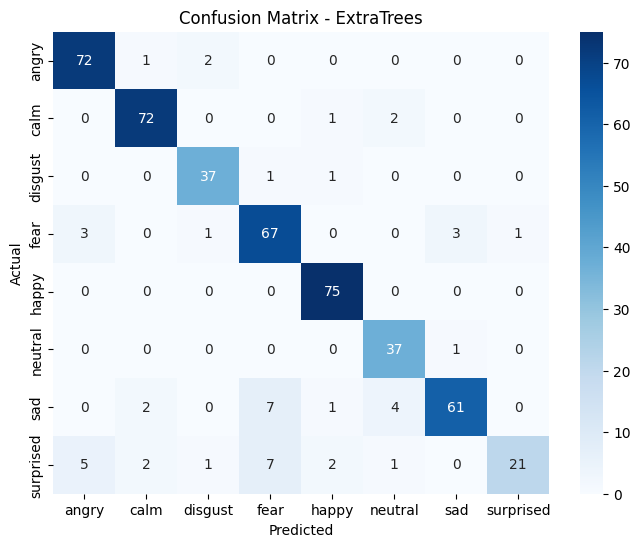

In [ ]:
# =========================
# 18. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 20 Important Features:
           Feature  Importance
199  AU12_c_median    0.022056
195    AU12_c_mean    0.017082
110    AU12_r_mean    0.013996
114  AU12_r_median    0.013459
179  AU06_c_median    0.012432
165    AU04_c_mean    0.012183
169  AU04_c_median    0.011901
194  AU10_c_median    0.011487
168     AU04_c_max    0.010369
190    AU10_c_mean    0.009880
175    AU06_c_mean    0.008729
188     AU09_c_max    0.008706
108     AU10_r_max    0.008436
150    AU45_r_mean    0.008345
191     AU10_c_std    0.007774
120    AU15_r_mean    0.007644
154  AU45_r_median    0.007610
83      AU04_r_max    0.007593
124  AU15_r_median    0.007579
193     AU10_c_max    0.007516


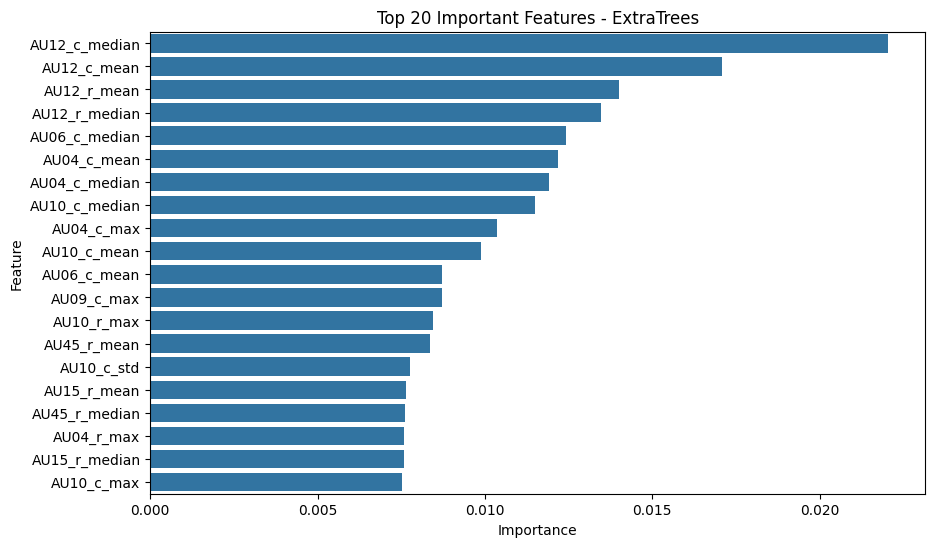

In [ ]:
# =========================
# 19. Feature importance
# =========================
clf = best_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    feature_names = X.columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(20)

    print("\nTop 20 Important Features:")
    print(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Top 20 Important Features - {best_model_name}")
    plt.show()


In [ ]:
# =========================
# 20. Show sample predictions
# =========================
X_test_df = X_test.copy()
X_test_df["Actual"] = label_encoder.inverse_transform(y_test)
X_test_df["Predicted"] = label_encoder.inverse_transform(y_test_pred)

sample_results = X_test_df[["Actual", "Predicted"]].sample(min(15, len(X_test_df)), random_state=42)
print("\nSample Predictions:")
display(sample_results)


Sample Predictions:


,Actual,Predicted
1852,happy,happy
1822,surprised,surprised
1634,happy,happy
1976,angry,angry
2014,sad,sad
1099,disgust,disgust
1818,calm,calm
1505,happy,happy
450,happy,happy
2198,angry,angry


In [ ]:
# =========================
# 21. Save best model
# =========================
save_dir = "/content/drive/MyDrive/face_csv_emotion_model"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "best_face_emotion_model.pkl")
label_path = os.path.join(save_dir, "label_encoder.pkl")
feature_path = os.path.join(save_dir, "feature_columns.pkl")

joblib.dump(best_model, model_path)
joblib.dump(label_encoder, label_path)
joblib.dump(list(X.columns), feature_path)

print("\nSaved files:")
print(model_path)
print(label_path)
print(feature_path)


Saved files:
/content/drive/MyDrive/face_csv_emotion_model/best_face_emotion_model.pkl
/content/drive/MyDrive/face_csv_emotion_model/label_encoder.pkl
/content/drive/MyDrive/face_csv_emotion_model/feature_columns.pkl


In [ ]:
# =========================
# 22. Predict one CSV file
# =========================
def predict_single_csv(file_path, model_path, label_path, feature_path, selected_cols):
    model = joblib.load(model_path)
    label_encoder = joblib.load(label_path)
    feature_columns = joblib.load(feature_path)

    feats = extract_features_from_csv(file_path, selected_cols)
    row = pd.DataFrame([feats])

    for c in feature_columns:
        if c not in row.columns:
            row[c] = 0

    row = row[feature_columns]

    pred_encoded = model.predict(row)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    confidence = None
    if hasattr(model.named_steps["clf"], "predict_proba"):
        probs = model.predict_proba(row)[0]
        confidence = float(np.max(probs))

    return pred_label, confidence

# Example prediction on first file
example_file = csv_files[0]
pred_label, confidence = predict_single_csv(
    example_file,
    model_path,
    label_path,
    feature_path,
    selected_cols
)

print("\nExample file prediction:")
print("File:", example_file)
print("Predicted emotion:", pred_label)
if confidence is not None:
    print("Confidence:", round(confidence, 4))


Example file prediction:
File: /content/drive/MyDrive/Face dataset/01-01-01-01-01-01-06.csv
Predicted emotion: neutral
Confidence: 0.604
